In [1]:
 import pandas as pd


In [2]:
df=pd.read_csv('customer_shopping_behavior.csv')

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [11]:

df.shape

(3900, 18)

In [13]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [15]:
df.columns= df.columns.str.lower()

In [17]:
df.columns= df.columns.str.replace(" ","_")

In [19]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [21]:
# create an age group.
labels = ['young','adult','middle_age','senior']
df['age_group']= pd.qcut(df['age'], q=4, labels=labels)

In [23]:
df[['age','age_group']]

,age,age_group
0,55,middle_age
1,19,young
2,50,middle_age
3,21,young
4,45,middle_age
...,...,...
3895,40,adult
3896,52,middle_age
3897,46,middle_age
3898,44,adult


In [25]:
df.isnull().sum()

customer_id                0
age                        0
gender                     0
item_purchased             0
category                   0
purchase_amount_(usd)      0
location                   0
size                       0
color                      0
season                     0
review_rating             37
subscription_status        0
shipping_type              0
discount_applied           0
promo_code_used            0
previous_purchases         0
payment_method             0
frequency_of_purchases     0
age_group                  0
dtype: int64

In [27]:
df['review_rating'] = df.groupby('category')['review_rating'].transform (lambda X: X.fillna(X.median()))           

In [29]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount_(usd)     0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
age_group                 0
dtype: int64

In [31]:
import numpy as np

In [33]:
# purches_frequensy_days
frequency_mapping= {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purches_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [35]:
df[['purches_frequency_days','frequency_of_purchases']].head(10)

,purches_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [37]:
(df['discount_applied'] == df['promo_code_used']).all()

True

In [39]:
df = df.drop('promo_code_used', axis=1)

In [41]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purches_frequency_days'],
      dtype='object')

In [43]:
categorycal_columns= df.select_dtypes(include='object').columns

In [45]:
df[categorycal_columns]

,gender,item_purchased,category,location,size,color,season,subscription_status,shipping_type,discount_applied,payment_method,frequency_of_purchases
0,Male,Blouse,Clothing,Kentucky,L,Gray,Winter,Yes,Express,Yes,Venmo,Fortnightly
1,Male,Sweater,Clothing,Maine,L,Maroon,Winter,Yes,Express,Yes,Cash,Fortnightly
2,Male,Jeans,Clothing,Massachusetts,S,Maroon,Spring,Yes,Free Shipping,Yes,Credit Card,Weekly
3,Male,Sandals,Footwear,Rhode Island,M,Maroon,Spring,Yes,Next Day Air,Yes,PayPal,Weekly
4,Male,Blouse,Clothing,Oregon,M,Turquoise,Spring,Yes,Free Shipping,Yes,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...
3895,Female,Hoodie,Clothing,Virginia,L,Turquoise,Summer,No,2-Day Shipping,No,Venmo,Weekly
3896,Female,Backpack,Accessories,Iowa,L,White,Spring,No,Store Pickup,No,Bank Transfer,Bi-Weekly
3897,Female,Belt,Accessories,New Jersey,L,Green,Spring,No,Standard,No,Venmo,Quarterly
3898,Female,Shoes,Footwear,Minnesota,S,Brown,Summer,No,Express,No,Venmo,Weekly


In [47]:
numeric_columns = df.select_dtypes(include='number').columns

In [49]:
df[numeric_columns]

,customer_id,age,purchase_amount_(usd),review_rating,previous_purchases,purches_frequency_days
0,1,55,53,3.1,14,14
1,2,19,64,3.1,2,14
2,3,50,73,3.1,23,7
3,4,21,90,3.5,49,7
4,5,45,49,2.7,31,365
...,...,...,...,...,...,...
3895,3896,40,28,4.2,32,7
3896,3897,52,49,4.5,41,14
3897,3898,46,33,2.9,24,90
3898,3899,44,77,3.8,24,7


In [51]:
# Create a function to calculate IQR-based outliers for all numeric columns
def iqr_outlier_summary(data):
    outlier_summary = []
    numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns

    for col in numeric_columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_condition = (data[col] < lower_bound) | (data[col] > upper_bound)
        outlier_count = outlier_condition.sum()
        total_count = len(data[col])
        outlier_percentage = round((outlier_count / total_count) * 100, 2)

        outlier_summary.append({
            'Column': col,
            'Outlier_Count': outlier_count,
            'Total_Values': total_count,
            'Outlier_Percentage': outlier_percentage
        })

    return pd.DataFrame(outlier_summary)

# Run the function and display summary
outlier_df = iqr_outlier_summary(df)
print(outlier_df.sort_values(by='Outlier_Percentage', ascending=False))


                   Column  Outlier_Count  Total_Values  Outlier_Percentage
5  purches_frequency_days            572          3900               14.67
0             customer_id              0          3900                0.00
1                     age              0          3900                0.00
2   purchase_amount_(usd)              0          3900                0.00
3           review_rating              0          3900                0.00
4      previous_purchases              0          3900                0.00


there is no outlier only purches_frequency_days columns contains some outlier but these outliers are valid

In [54]:
df.head(5)

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purches_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,middle_age,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,young,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,middle_age,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,young,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,middle_age,365


In [56]:
df['payment_method'].unique()

array(['Venmo', 'Cash', 'Credit Card', 'PayPal', 'Bank Transfer',
       'Debit Card'], dtype=object)

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set(style="whitegrid")


UNIVARIATE ANALYSIS

C:\Users\artsa\AppData\Local\Temp\ipykernel_13612\1519221948.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="gender", palette="pastel")


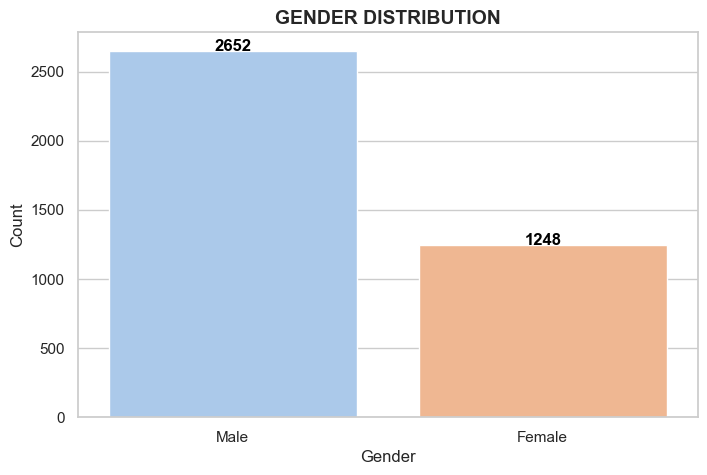

In [60]:

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

# Create the countplot
ax = sns.countplot(data=df, x="gender", palette="pastel")

# Add title and labels
plt.title("GENDER DISTRIBUTION", fontsize=14, fontweight='bold')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add count labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.,   # X position
        height + 0.5,                     # Y position slightly above the bar
        int(height),                      # The count value
        ha="center",                      # Center alignment
        fontsize=12,
        color="black",
        fontweight="bold"
    )

plt.show()


In [61]:
df.head(5)

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purches_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,middle_age,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,young,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,middle_age,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,young,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,middle_age,365


In [62]:
df['category'].unique()

array(['Clothing', 'Footwear', 'Outerwear', 'Accessories'], dtype=object)

C:\Users\artsa\AppData\Local\Temp\ipykernel_13612\3349443735.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.index,y=top_products.values, palette="Paired")


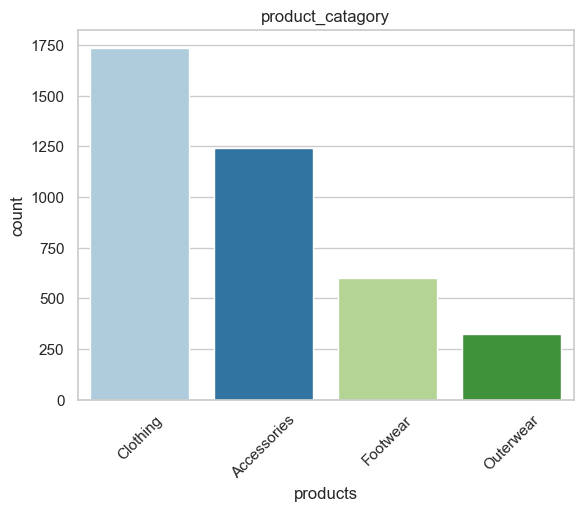

In [67]:
top_products=df['category'].value_counts().nlargest(4)
sns.barplot(x=top_products.index,y=top_products.values, palette="Paired")
plt.title("product_catagory")
plt.xlabel("products")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.show()

C:\Users\artsa\AppData\Local\Temp\ipykernel_13612\1797602297.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_distribution.index,y=age_distribution.values, palette="Paired")


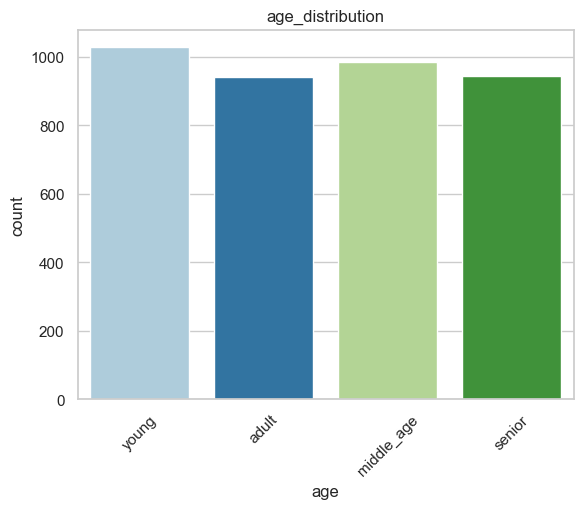

In [69]:
# Purchases distribution by age

age_distribution=df['age_group'].value_counts().nlargest(5)
sns.barplot(x=age_distribution.index,y=age_distribution.values, palette="Paired")
plt.title("age_distribution")
plt.xlabel("age")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.show()


In [71]:
df.head(5)

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purches_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,middle_age,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,young,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,middle_age,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,young,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,middle_age,365


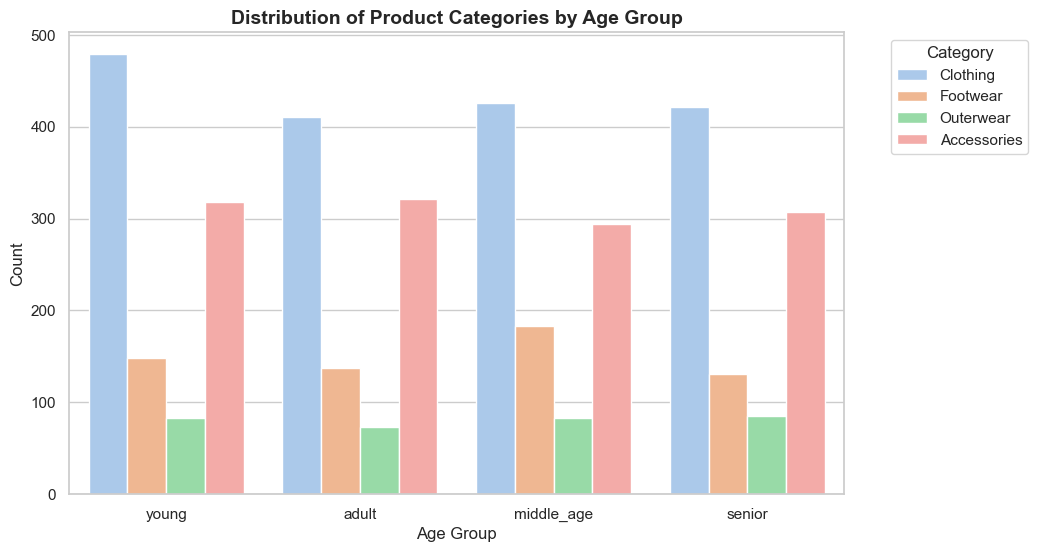

In [73]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="age_group", hue="category", palette="pastel")

plt.title("Distribution of Product Categories by Age Group", fontsize=14, fontweight='bold')
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


C:\Users\artsa\AppData\Local\Temp\ipykernel_13612\1430906276.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="subscription_status", palette="Set2")


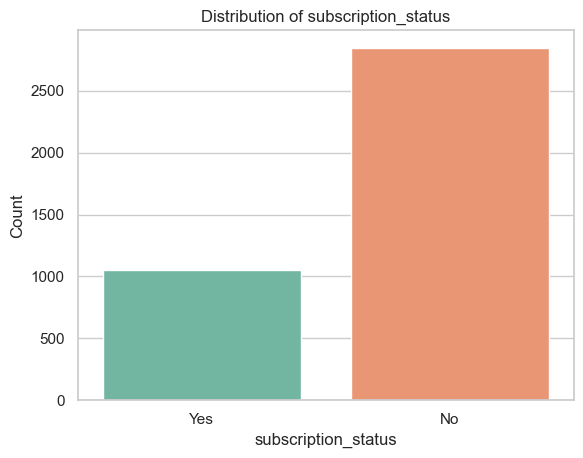

In [75]:
sns.countplot(data=df, x="subscription_status", palette="Set2")
plt.title("Distribution of subscription_status")
plt.xlabel("subscription_status")
plt.ylabel("Count")
plt.show()


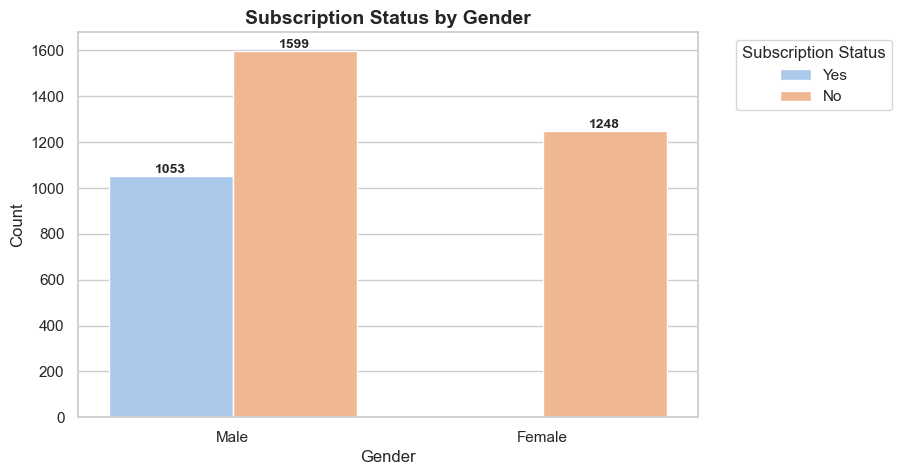

In [77]:
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

# Create grouped bar plot
sub_plot = sns.countplot(data=df, x="gender", hue="subscription_status", palette="pastel")

# Add count labels on each bar
for container in sub_plot.containers:
    sub_plot.bar_label(container, fontsize=10, fontweight='bold')

plt.title("Subscription Status by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Subscription Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


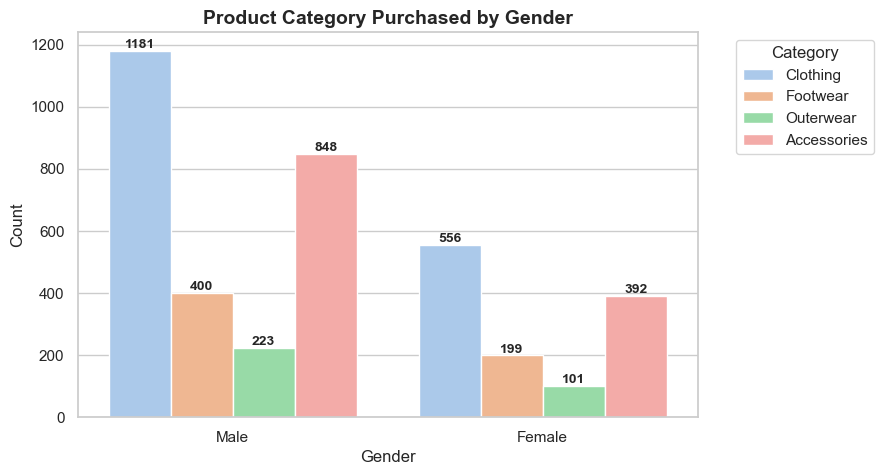

In [79]:
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

# Create grouped bar plot
gen_cat = sns.countplot(data=df, x="gender", hue="category", palette="pastel")

# Add count labels on each bar
for container in gen_cat.containers:
    gen_cat.bar_label(container, fontsize=10, fontweight='bold')

plt.title("Product Category Purchased by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [81]:
!pip install pymysql sqlalchemy pandas 

In [82]:
from sqlalchemy import create_engine
import pandas as pd

# MySQL connection details
username = "root"
password = "SKNayak#2002@"      # ✅ Use quotes and escape special chars if needed
host = "127.0.0.1"              # Localhost (can also use 'localhost')
port = "3306"
database = "customer_shopping_behavior"

from urllib.parse import quote_plus
password = quote_plus("SKNayak#2002@")


# ✅ Create SQLAlchemy Engine
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# ✅ Table name
table_name = "customer_table"

# ✅ Upload DataFrame to MySQL (replace if already exists)
df.to_sql(table_name, engine, if_exists="replace", index=False)

# ✅ Read back sample rows
result = pd.read_sql("SELECT * FROM customer_table LIMIT 5;", engine)
print(result)


   customer_id  age gender item_purchased  category  purchase_amount_(usd)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        location size      color  season  review_rating subscription_status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   shipping_type discount_applied  previous_purchases pa